<a href="https://colab.research.google.com/github/nithzsenpai/mL-lab/blob/main/1BM23CS219LAB9_KMEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('/content/iris (2).csv')
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Preprocessing: Selecting Features and Scaling

K-Means clustering relies on distance metrics, so scaling features is crucial when they have different ranges or units. Here, we'll select `petal_width` and `petal_length` and then apply `StandardScaler` to normalize them.

In [2]:
# Select features for clustering
X = df[['petal_length', 'petal_width']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features (first 5 rows):")
display(pd.DataFrame(X_scaled, columns=X.columns).head())

Scaled features (first 5 rows):


,petal_length,petal_width
0,-1.341272,-1.312977
1,-1.341272,-1.312977
2,-1.398138,-1.312977
3,-1.284407,-1.312977
4,-1.341272,-1.312977


### Elbow Plot to Determine Optimal K

The Elbow method is a heuristic used to determine the optimal number of clusters in K-Means clustering. It involves calculating the Within-Cluster Sum of Squares (WCSS) for different values of `k` and plotting them. The 'elbow' point in the graph, where the rate of decrease in WCSS significantly changes, is considered the optimal `k`.

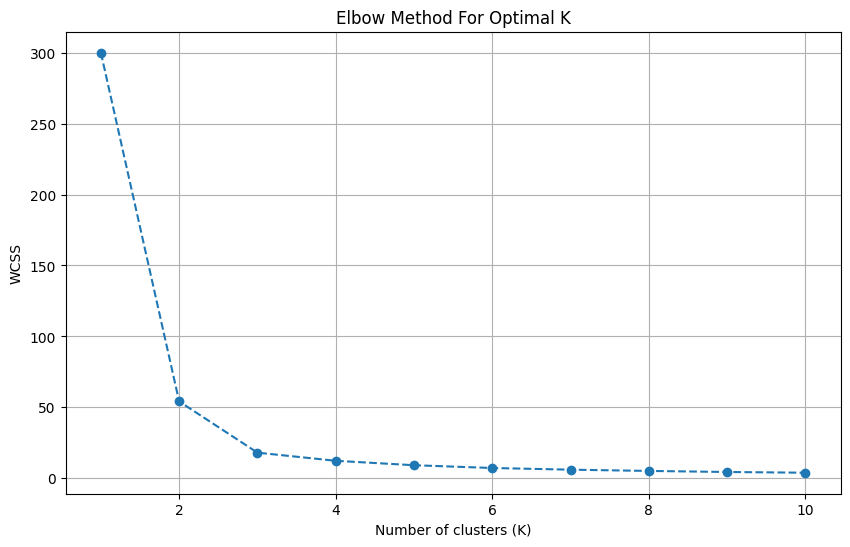

In [3]:
wcss = []
# Test k from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### K-Means Clustering with Optimal K

Based on the elbow plot, an optimal number of clusters (K) appears to be 3. Now, we'll apply K-Means with `n_clusters=3` to our scaled data and then visualize the clusters.

In [ ]:
# Apply K-Means clustering with the optimal K (e.g., 3 from the elbow plot)
k = 3  # Assuming k=3 is the optimal value from the elbow plot
kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original (unscaled) DataFrame for easier interpretation
df['cluster'] = y_kmeans

print("First 5 rows with cluster assignments:")
display(df.head())

### Visualizing the Clusters

To better understand the clustering results, we'll visualize the clusters on a scatter plot using `petal_length` and `petal_width`. Each cluster will be represented by a different color, and the cluster centers will be marked.

In [ ]:
# Visualize the clusters
plt.figure(figsize=(10, 7))

# Scatter plot for each cluster
for i in range(k):
    plt.scatter(
        X_scaled[y_kmeans == i, 0],
        X_scaled[y_kmeans == i, 1],
        s=100,
        label=f'Cluster {i+1}'
    )

# Plot the cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Clusters of Iris Flowers (Scaled Petal Length vs. Petal Width)')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.legend()
plt.grid(True)
plt.show()